In [3]:
using DrWatson

@quickactivate "ReservoirInverseDesign"

projectname()

"ReservoirInverseDesign"

In [4]:
using CairoMakie

In [5]:
using DifferentialEquations
using LinearAlgebra
using Random
using Statistics
using Distributed

using Lux
using Metal
# using LuxCUDA
using LuxCore
using NeuralOperators
using Optimisers
using Optimization
using OptimizationMultistartOptimization
using OptimizationMetaheuristics
using OptimizationBBO
using OptimizationOptimJL
using Zygote
using Enzyme
using Reactant

using JLD2


In [6]:
Threads.nthreads()

8

In [7]:
dev = reactant_device(; force=true)

(::ReactantDevice{Missing, Missing, Missing, Missing, Union{}}) (generic function with 1 method)

In [12]:
include(srcdir("kdV_Reservoir_Surrogate.jl"))
include(srcdir("experiments/Reservoir_1.jl"));

In [13]:
fno_train = false

false

In [14]:
rng = Random.MersenneTwister(42);

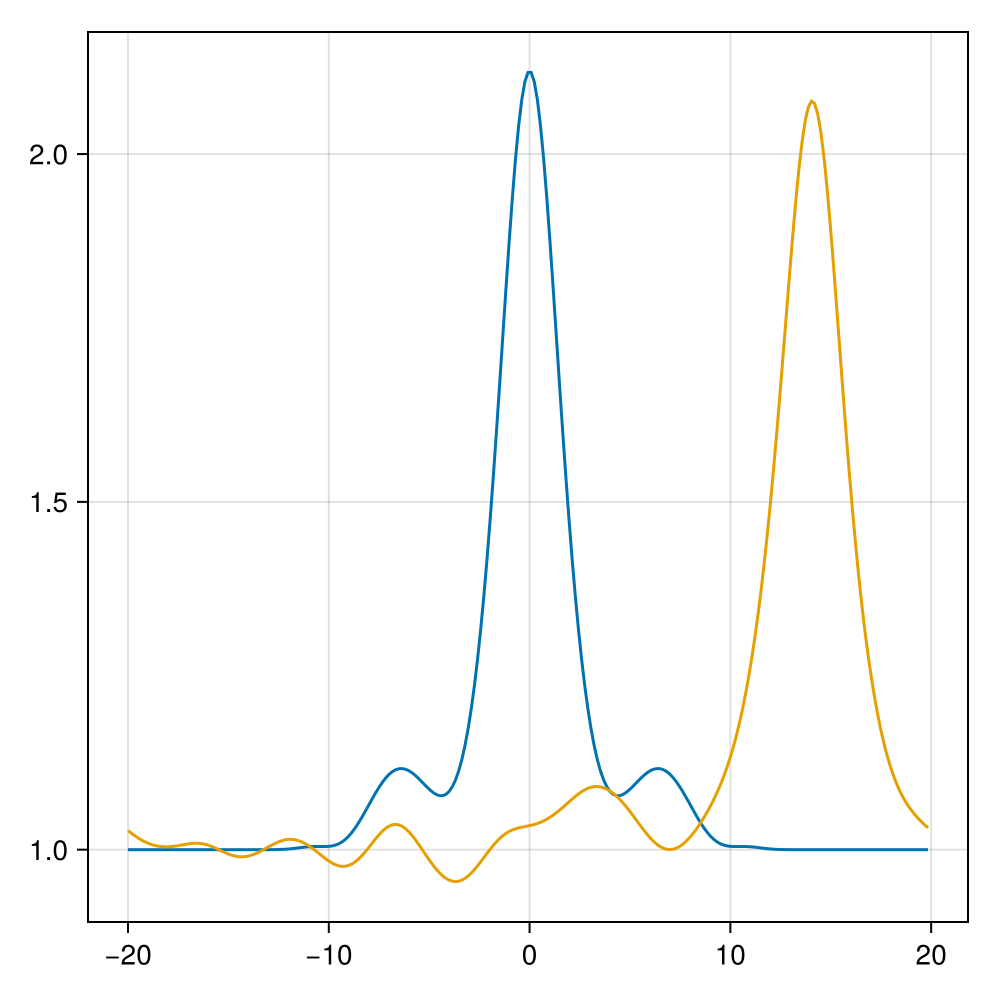

In [15]:
θ = [0.05, 0.20, 0.07, 0.24, 0.433, 0.500,20]

u01 = encode_initial_condition_7(X_BITS[1], x, θ, p_soliton)

prob_01 = ODEProblem(kdv_fd!, u01, (0.0, 10.0), p_reservoir)

sol = solve(prob_01, AutoVern7(RadauIIA5()));

u_final = sol.u[end]

fig = CairoMakie.Figure(size = (500,500))
ax = Axis(fig[1,1])

lines!(ax,x,u01)
lines!(ax,x,u_final)

fig

In [16]:
# -----------------------
# load training data
# -----------------------

data = load(datadir("exp_raw/kdV/kdV_train_2500_500.jld2"))

X_train = data["X_train"]
Y_train = data["Y_train"]

X_test = data["X_test"]
Y_test = data["Y_test"]

meta_train = data["meta_train"]
meta_test = data["meta_test"];

Loading FNO...


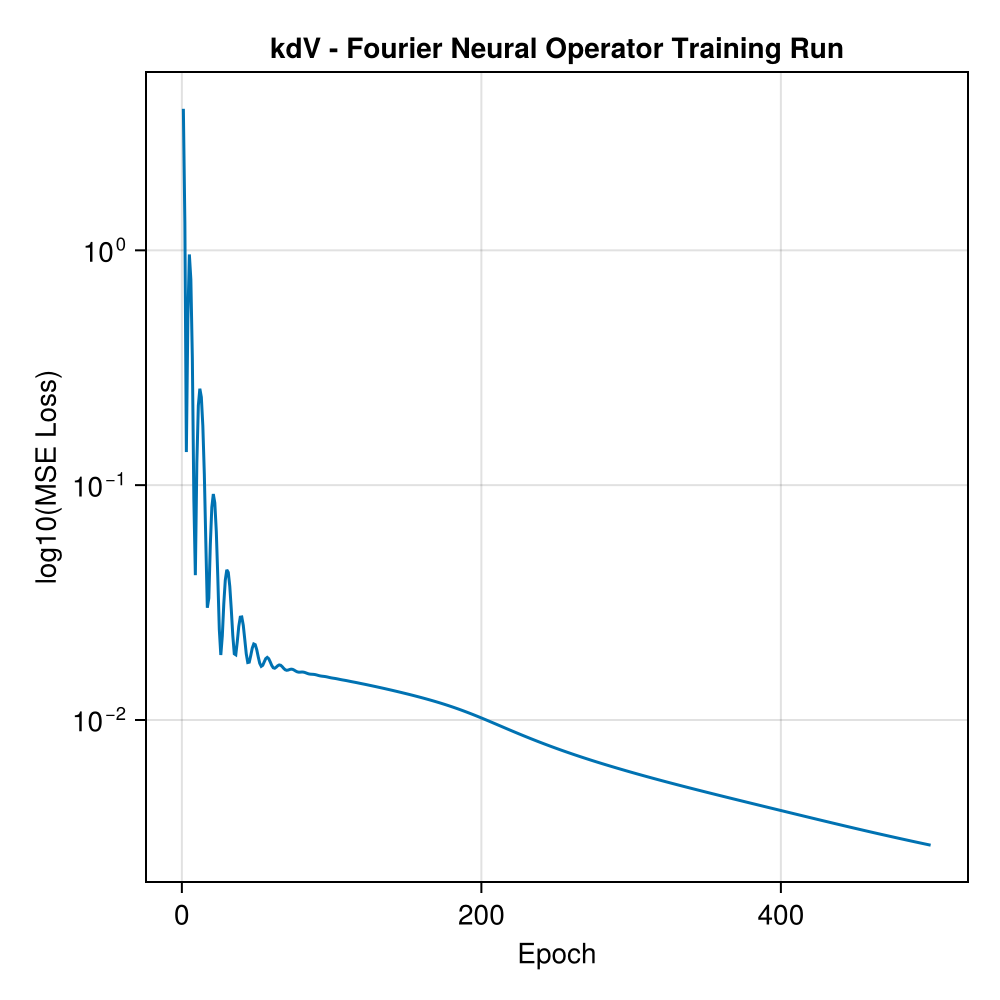

In [17]:
 if fno_train

    # ------------------------
    # Train FNO surrogate
    # ------------------------

    println("Training FNO...")

    fno_width = 32
    fno_modes = 16
    training_epochs = 1000

    fno, ps, st, losses = train_fno(
        X_train,
        Y_train;
        width = fno_width,
        modes = fno_modes,
        epochs = training_epochs ,
        lr = 3f-3,
        rng = rng,
        xdev = dev,
    )

    println("Final training loss = ", losses[end])

    ps_cpu = ps |> cpu_device()
    st_cpu = st |> cpu_device()

    fno_data_dict = Dict()
    fno_data_dict["width"] = fno_width
    fno_data_dict["modes"] = fno_modes
    fno_data_dict["ps"] = ps_cpu
    fno_data_dict["st"] = st_cpu
    fno_data_dict["losses"] = losses

    save(datadir("exp_raw","fno_trained_TD2500_TE500_Epochs" * string(training_epochs) * ".jld2"),fno_data_dict)

 else

    println("Loading FNO...")

    fno_model = load(datadir("exp_raw","fno_trained_TD2500_TE500_Epochs500.jld2"))

    fno_width = fno_model["width"]
    fno_modes = fno_model["modes"]

    fno = FourierNeuralOperator(
        gelu;
        chs = (1, fno_width, fno_width, 2fno_width, 1),
        modes = (fno_modes,),
    )

    ps_cpu = fno_model["ps"]
    st_cpu = fno_model["st"]
    losses = fno_model["losses"]
 end

 fig = CairoMakie.Figure(size = (500,500))
 ax = Axis(fig[1,1],xlabel = "Epoch",ylabel = "log10(MSE Loss)", yscale = log10,title = "kdV - Fourier Neural Operator Training Run")
 
 lines!(ax,losses)
 
 fig

In [18]:
# ------------------------
# Inverse design, surrogate model
#
# ------------------------

n_readouts = 4
θ0 = [0.05, 0.20, 0.07, 0.24, 0.433, 0.500, 20.0]
xreadout0 = collect(range(-8.0, 8.0, length=n_readouts))

println("Optimizing theta + readout positions...")

sol = optimize_theta_and_readouts(
    fno,
    ps_cpu,
    st_cpu,
    θ0,
    xreadout0,
    lb_theta,
    ub_theta,
    x,
    p_soliton;
    λ_rep = 1f-3,
    sigma = 1.5 * dx,
    nstarts = 100,
)

zbest = Array(sol.u)
θ_best = zbest[1:7]
xread_best = zbest[8:end]

println("θ_best = ", θ_best)
println("xread_best = ", xread_best)

Optimizing theta + readout positions...


┌ Warning: Slow fallback implementation invoked for conv!  You probably don't want this; check your datatypes.
│   yT = Float64
│   T1 = Float64
│   T2 = Float32
└ @ NNlib /Users/boothh/.julia/packages/NNlib/srXYX/src/conv.jl:192
┌ Warning: Slow fallback implementation invoked for conv!  You probably don't want this; check your datatypes.
│   yT = Float64
│   T1 = Float64
│   T2 = Float32
└ @ NNlib /Users/boothh/.julia/packages/NNlib/srXYX/src/conv.jl:192
┌ Warning: Slow fallback implementation invoked for conv!  You probably don't want this; check your datatypes.
│   yT = Float64
│   T1 = Float64
│   T2 = Float32
└ @ NNlib /Users/boothh/.julia/packages/NNlib/srXYX/src/conv.jl:192
┌ Warning: Slow fallback implementation invoked for conv!  You probably don't want this; check your datatypes.
│   yT = Float64
│   T1 = Float64
│   T2 = Float32
└ @ NNlib /Users/boothh/.julia/packages/NNlib/srXYX/src/conv.jl:192


┌ Warning: Slow fallback implementation invoked for ∇conv_data!  You probably don't want this; check your datatypes.
│   yT = Float64
│   T1 = Float64
│   T2 = Float32
└ @ NNlib /Users/boothh/.julia/packages/NNlib/srXYX/src/conv.jl:243


θ_best = 

[0.009999999783692967, 0.3499999940341171, 0.3499999940342742, 0.009999999785778627, 0.6289163356546192, 0.28418377230819175, 25.76994293791537]
xread_best = [13.342600684176107, 4.0605273756827565, 15.14077613138174, 0.19470794325581547]


In [19]:
# ------------------------
# Surrogate score
# ------------------------

R_hat = surrogate_readout_matrix(
    fno, ps_cpu, st_cpu, θ_best, xread_best, x, p_soliton;
    sigma = 1.5 * dx,
)
println("Surrogate R = ")
display(R_hat)
println("Surrogate separability score = ", separability_score(R_hat))


# ------------------------
# Ground-truth PDE validation
# ------------------------

println("Validating on the full PDE...")

R_true = true_readout_matrix(
    θ_best,
    xread_best,
    x,
    prob,
    t_end,
    p_soliton;
    sigma = 1.5 * dx,
    reltol = 1e-10,
    abstol = 1e-10,
)

println("True R = ")
display(R_true)
println("True separability score = ", separability_score(R_true))

if size(R_true, 1) == size(R_true, 2)
    surrogate_best_fitness = abs(det(R_true))
    println("True |det(R)| = ", surrogate_best_fitness)
else
    surrogate_best_fitness = det(R_true * R_true')
    println("True det(RR') = ", surrogate_best_fitness)
end

Surrogate R = 


4×4 Matrix{Float64}:
 1.42769  1.08212   2.22867  1.24601
 1.88655  0.993206  1.78008  1.01181
 1.07682  1.47      1.82997  1.22302
 1.62995  1.33741   2.18868  1.01905

Surrogate separability score = -1.2462446458423118


Validating on the full PDE...
True R = 

4×4 Matrix{Float64}:
 1.40186  1.03841  2.43848  1.28182
 2.00498  1.00396  1.53382  1.00863
 1.15055  1.40499  1.54365  1.4264
 1.6445   1.28704  2.21717  0.966088


True separability score = -0.1763790126343289
True |det(R)| = 0.8382991967523858


In [20]:
# n_fno_training_samples = Int(size(X_train,1) / 4)

n_fno_training_samples = 2500

alg_names = ["Adaptive_Differential_Evolution","Exponential_NES","Generating_Set_Search"]
alg_methods = [BBO_adaptive_de_rand_1_bin_radiuslimited(),BBO_xnes(),BBO_generating_set_search()]

alg_best_determinants = []
alg_sol = []

for (alg_name,alg) in zip(alg_names,alg_methods)

    println("Optimizing theta + readout positions for " * alg_name * "...")

    meta_alg = false

    sol_opt = optimize_theta_and_readouts_BBO(
        prob,
        t_end,
        θ0,
        xreadout0,
        lb_theta,
        ub_theta,
        x,
        p_soliton;
        MaxFuncEvals = n_fno_training_samples,
        λ_rep = 1f-3,
        sigma = 1.5 * dx,
        alg = alg,
        meta_alg = meta_alg,
        nthreads = 7,
    )

    zbest = Array(sol_opt.u)
    θ_best = zbest[1:7]
    xread_best = zbest[8:end]

    R_true = true_readout_matrix(
                    θ_best,
                    xread_best,
                    x,
                    prob,
                    t_end,
                    p_soliton;
                    sigma = 1.5 * dx)

    
    println("separability score = ", separability_score(R_true))

    if size(R_true, 1) == size(R_true, 2)
        fitness = abs(det(R_true))
        println("True |det(R)| = ", fitness)
    else
        fitness = det(R_true * R_true')
        println("True det(RR') = ", fitness)
    end

    push!(alg_best_determinants,fitness)
    push!(alg_sol,sol_opt)

end



Optimizing theta + readout positions for Adaptive_Differential_Evolution...


┌ Info: MultithreadEvaluator: 7 workers ready, starting
└ @ BlackBoxOptim /Users/boothh/.julia/packages/BlackBoxOptim/18seW/src/multithread_evaluator.jl:224


In [ ]:
alg_comparison_det = vcat([surrogate_best_fitness],alg_best_determinants)
alg_comparison_names = vcat(["NO_Surrogate + gradient_based"],alg_names)

fig = CairoMakie.Figure(size = (500,500))

ax = Axis(fig[1,1],xlabel = "Search algorithm",ylabel = "True |det(R)|",title = "kdV RID: search comparison w/ 2500 function evals")

scatter!(ax,[i for i in 1:length(alg_comparison_det)],alg_comparison_det)

ax.xticks = (1:length(alg_comparison_det),alg_comparison_names)
ax.xticklabelrotation = 45.

fig